# DLinear vs. your Tensor-Decomposition + AR pipeline (M4)

This notebook runs **your existing pipeline** (PARAFAC tensor decomposition + per-factor `AutoReg`)
side-by-side with **DLinear** on the *exact same* data slice, split, and metrics, so the numbers are
directly comparable.

**What's kept identical to your `m4.ipynb`:**
- Same 5 series selected from `Monthly-train.csv` (`df.iloc[13:18, 1:PERIOD*TIME+1]`)
- Same `(PERIOD=25, TIME=12, FEATURES=5)` reshape
- Same `TRAIN_DAYS=20` / `TEST_DAYS=5` split (240 train steps, 60 test steps)
- Same evaluation metrics: R², MSE, MAE, RMSE, computed **per feature** on the 60 held-out steps

**What has to differ:**
- Your tensor-AR method fits directly on the single 20-period series (no separate training set needed
  — it's decomposition + a tiny autoregressive model on the latent factors).
- DLinear is a supervised `seq_len -> pred_len` regressor, so it needs multiple example windows to
  learn from. Those windows are cut **only** from the 240 training steps (sliding windows), and the
  60 test steps are only ever used once, at the very end, for scoring — never for fitting. So the
  comparison stays apples-to-apples: both models only ever see the same 240 training points before
  being scored on the same held-out 60 points.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

np.random.seed(2023)
torch.manual_seed(2023)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Data loading — identical to your notebook

In [30]:
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = 12   # if monthly --> 12, else if daily --> 24
FEATURES = 5

df = pd.read_csv("dataset/m4/Train/Monthly-train.csv")

# same 5 series as your notebook
df_selected = df.iloc[13:18, 1:PERIOD * TIME + 1]
df = df_selected.T

data = df[df.columns.to_list()][:PERIOD * TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES).astype(np.float64)

train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS + TEST_DAYS, :, :]

# flattened (time, features) views used by both models below
train_series = train_tensor.reshape(-1, FEATURES).astype(np.float32)   # (240, 5)
test_series = test_tensor.reshape(-1, FEATURES).astype(np.float32)     # (60, 5)

print("train_series:", train_series.shape, " test_series:", test_series.shape)


train_series: (240, 5)  test_series: (60, 5)


## 2. Baseline — your Tensor Decomposition + AR pipeline

Condensed re-run of your existing cells (PARAFAC rank-2 decomposition, `AutoReg(lags=1)` on each
latent day-factor, tensor reconstruction) so its forecast is available for the comparison table below.


In [31]:
from tensorly.decomposition import parafac
from tensorly import cp_to_tensor
from statsmodels.tsa.ar_model import AutoReg

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
day_factors, time_factors, feature_factors = factors

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    ar_model = AutoReg(series, lags=1, old_names=False)
    ar_fit = ar_model.fit()
    forecast_day_factors[:, r] = ar_fit.forecast(steps=TEST_DAYS)

forecast_tensor_ar = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor_ar[i, :, :] += weights[r] * np.outer(
            forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r]
        )

forecast_series_ar = forecast_tensor_ar.reshape(-1, FEATURES).astype(np.float32)  # (60, 5)
print("Tensor-AR forecast shape:", forecast_series_ar.shape)


Tensor-AR forecast shape: (60, 5)


## 3. Challenger — multivariate DLinear

Same architecture as `DLinear.py` (moving-average decomposition + one linear layer per component),
generalised to `FEATURES=5` channels. Trained on sliding windows drawn only from `train_series`.


In [32]:
class moving_avg(nn.Module):
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        return x.permute(0, 2, 1)


class series_decomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class DLinear(nn.Module):
    """Multivariate DLinear (channels shared, individual=False — matches the paper's default)."""
    def __init__(self, seq_len, pred_len, channels, moving_avg_kernel=25):
        super().__init__()
        self.decompsition = series_decomp(moving_avg_kernel)
        self.Linear_Seasonal = nn.Linear(seq_len, pred_len)
        self.Linear_Trend = nn.Linear(seq_len, pred_len)
        with torch.no_grad():
            self.Linear_Seasonal.weight.copy_((1 / seq_len) * torch.ones(pred_len, seq_len))
            self.Linear_Trend.weight.copy_((1 / seq_len) * torch.ones(pred_len, seq_len))

    def forward(self, x):
        # x: [B, seq_len, C]
        seasonal_init, trend_init = self.decompsition(x)
        seasonal_init, trend_init = seasonal_init.permute(0, 2, 1), trend_init.permute(0, 2, 1)
        seasonal_output = self.Linear_Seasonal(seasonal_init)
        trend_output = self.Linear_Trend(trend_init)
        out = seasonal_output + trend_output          # [B, C, pred_len]
        return out.permute(0, 2, 1)                    # [B, pred_len, C]


In [33]:
DL_SEQ_LEN = 60          # input window length
DL_PRED_LEN = TEST_DAYS * TIME   # 60, must match the held-out horizon
DL_MOVING_AVG = 25        # must be < DL_SEQ_LEN

def build_windows(series, seq_len, pred_len):
    """All sliding (input, target) windows fully inside `series`."""
    X, Y = [], []
    T = series.shape[0]
    for start in range(0, T - seq_len - pred_len + 1):
        X.append(series[start:start + seq_len])
        Y.append(series[start + seq_len:start + seq_len + pred_len])
    return np.stack(X), np.stack(Y)

X_train, Y_train = build_windows(train_series, DL_SEQ_LEN, DL_PRED_LEN)
print(f"Training windows: {X_train.shape[0]} (each {DL_SEQ_LEN} -> {DL_PRED_LEN}, {FEATURES} channels)")

X_train_t = torch.from_numpy(X_train).float().to(device)
Y_train_t = torch.from_numpy(Y_train).float().to(device)

dlinear = DLinear(DL_SEQ_LEN, DL_PRED_LEN, FEATURES, DL_MOVING_AVG).to(device)
optimizer = torch.optim.Adam(dlinear.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

EPOCHS = 500
for epoch in range(1, EPOCHS + 1):
    dlinear.train()
    optimizer.zero_grad()
    pred = dlinear(X_train_t)
    loss = loss_fn(pred, Y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:04d} | train MSE {loss.item():.4f}")


Training windows: 121 (each 60 -> 60, 5 channels)
Epoch 0001 | train MSE 675366.6250
Epoch 0100 | train MSE 17357.1172
Epoch 0200 | train MSE 15886.9619
Epoch 0300 | train MSE 15023.0635
Epoch 0400 | train MSE 14249.0186
Epoch 0500 | train MSE 13516.6074


In [34]:
dlinear.eval()
with torch.no_grad():
    last_window = torch.from_numpy(train_series[-DL_SEQ_LEN:]).float().unsqueeze(0).to(device)
    forecast_series_dlinear = dlinear(last_window).squeeze(0).cpu().numpy()  # (60, 5)

print("DLinear forecast shape:", forecast_series_dlinear.shape)


DLinear forecast shape: (60, 5)


## 4. Side-by-side metrics

Same metrics as your notebook (`r2_score`, `mean_squared_error`, `mean_absolute_error`,
`root_mean_squared_error`), computed per feature for both forecasts against the same `test_series`.


In [35]:
rows = []
for i in range(FEATURES):
    actual = test_series[:, i]
    for method_name, forecast in [("Tensor-AR (yours)", forecast_series_ar[:, i]),
                                   ("DLinear", forecast_series_dlinear[:, i])]:
        rows.append({
            "Feature": i,
            "Method": method_name,
            "R2": r2_score(actual, forecast),
            "MSE": mean_squared_error(actual, forecast),
            "MAE": mean_absolute_error(actual, forecast),
            "RMSE": root_mean_squared_error(actual, forecast),
        })

results_df = pd.DataFrame(rows).sort_values(["Feature", "Method"]).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
results_df


,Feature,Method,R2,MSE,MAE,RMSE
0,0,DLinear,-1.0559,54812.9609,204.2809,234.1217
1,0,Tensor-AR (yours),0.7352,7061.2412,65.6455,84.0312
2,1,DLinear,0.4783,7639.3389,79.6140,87.4033
3,1,Tensor-AR (yours),0.7811,3205.2571,44.5417,56.6150
4,2,DLinear,-1.6941,488503.0000,620.1312,698.9299
5,2,Tensor-AR (yours),0.2398,137836.6094,319.4696,371.2635
6,3,DLinear,-1.0265,293223.8750,475.2751,541.5015
7,3,Tensor-AR (yours),-0.0116,146374.3125,327.7368,382.5890
8,4,DLinear,0.6100,30511.4199,152.0186,174.6752
9,4,Tensor-AR (yours),0.9051,7423.8345,72.9614,86.1617


In [36]:
# Overall (macro-averaged across the 5 features) comparison
summary = results_df.groupby("Method")[["R2", "MSE", "MAE", "RMSE"]].mean()
summary


,R2,MSE,MAE,RMSE
Method,,,,
DLinear,-0.5376,174938.1189,306.2639,347.3263
Tensor-AR (yours),0.5299,60380.2509,166.0710,196.1321


## 5. Overlaid forecast plots

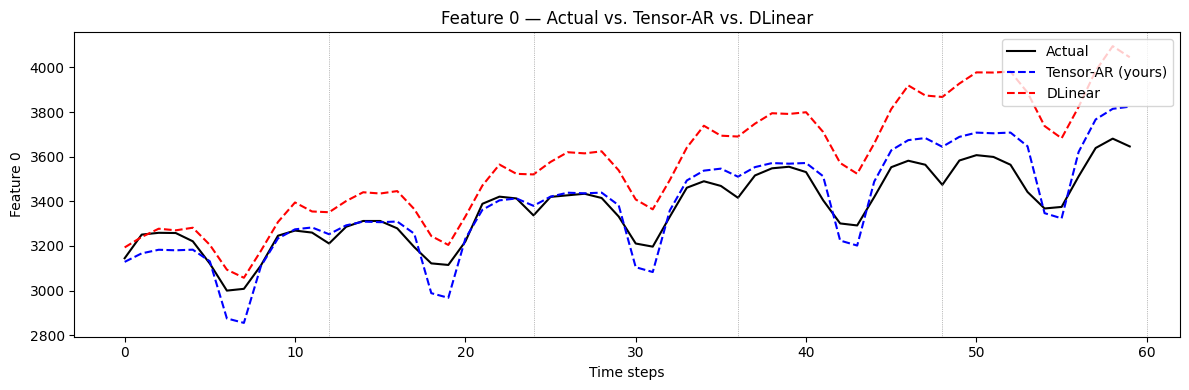

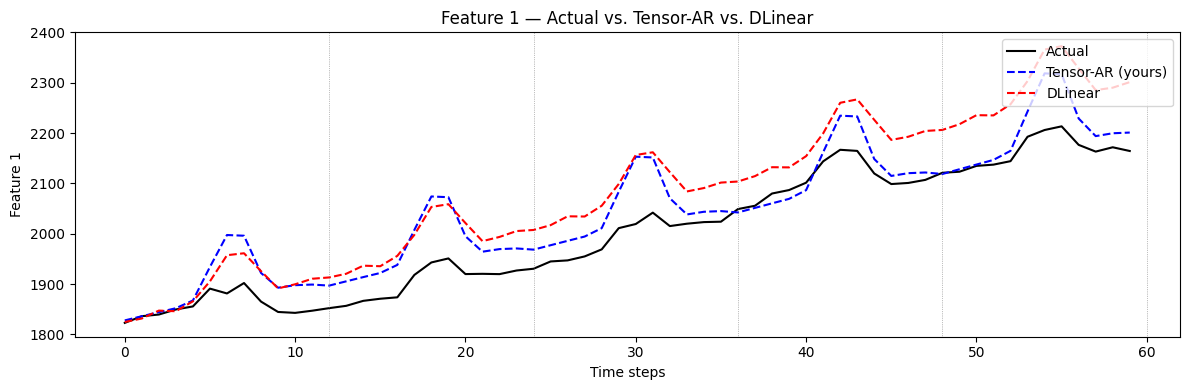

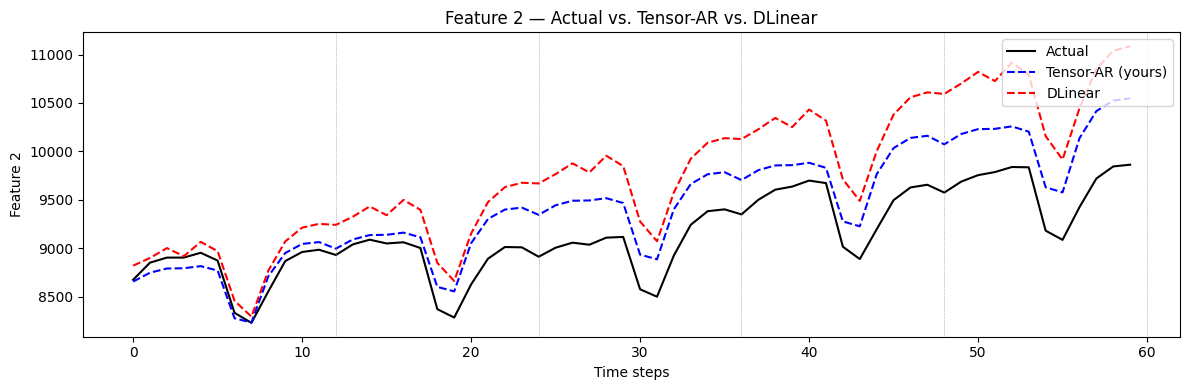

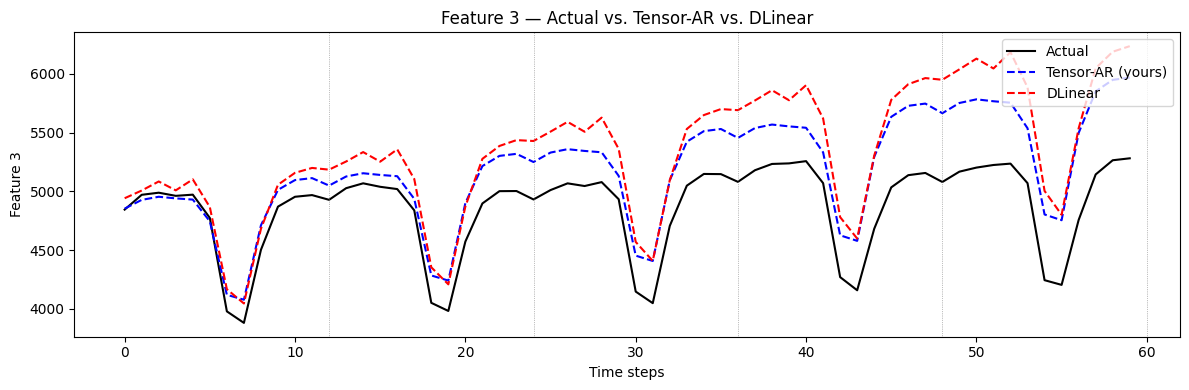

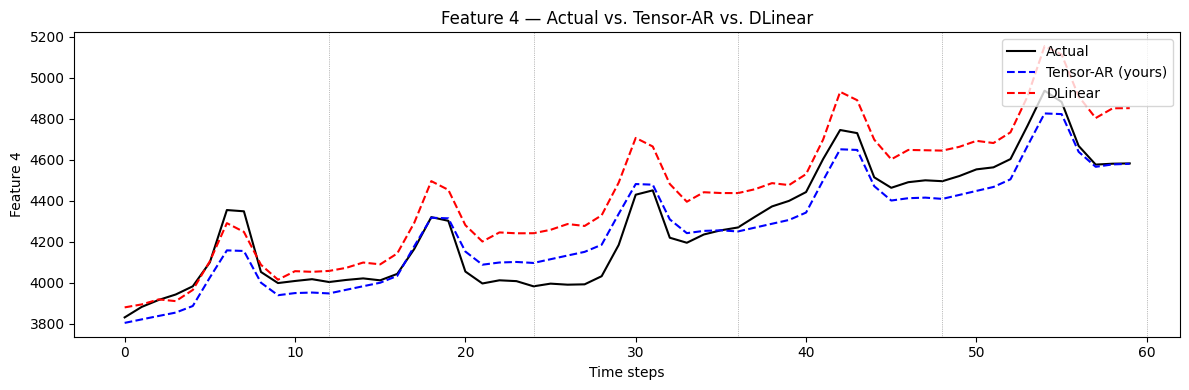

In [37]:
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(x, test_series[:, i], 'k-', lw=1.5, label='Actual')
    plt.plot(x, forecast_series_ar[:, i], 'b--', lw=1.5, label='Tensor-AR (yours)')
    plt.plot(x, forecast_series_dlinear[:, i], 'r--', lw=1.5, label='DLinear')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Feature {i} — Actual vs. Tensor-AR vs. DLinear')
    plt.xlabel('Time steps')
    plt.ylabel(f'Feature {i}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


## Notes on interpreting this comparison

- **Training data volume differs by design, not by unfairness**: the tensor-AR approach only ever
  needs the 240 raw points (it fits a rank-2 decomposition + AR(1) on 2 latent series of length 20).
  DLinear is a supervised regressor and needs example `(input, target)` pairs, so it's trained on
  overlapping windows *carved only from those same 240 points* — the 60 test points are never seen
  until the final forecast/scoring step, for either model.
- **`DL_SEQ_LEN`/`DL_MOVING_AVG` are tunable.** With only 240 training points, a longer `DL_SEQ_LEN`
  gives DLinear more context per window but fewer distinct training windows overall — worth trying
  a couple of values (e.g. 36, 60, 96) and comparing the summary table.
- **This is a very small-data regime** (5 series, 240 train points) — not the scale DLinear was
  benchmarked at in the paper (tens of thousands of steps per series). Treat this as a controlled,
  fair A/B on *your* task/data, not as a claim about which method is better in general.
- If you want DLinear scored the way the M4 competition itself scores forecasts (SMAPE/MASE/OWA
  instead of R²/MSE/MAE/RMSE), see the `DLinear_M4.ipynb` notebook from earlier — it implements
  those metrics directly.
